# ParkinDraw — Structural EDA dan Data-Readiness Review

Notebook ini melakukan Exploratory Data Analysis (EDA) komprehensif terhadap subset gambar statis NewHandPD setelah audit reproducible selesai.

Tujuan notebook:

- memahami shape, schema, tipe data, statistik deskriptif, dan kualitas metadata;
- memvisualisasikan distribusi class, drawing, subject, resolusi, ukuran file, dan statistik pixel;
- menganalisis anomali, exact duplicate, dan kandidat near-duplicate;
- menyediakan galeri visual dan manifest review near-duplicate;
- menentukan apakah data siap memasuki leakage-safe splitting pada Fase 2.

> EDA ini adalah structural/data-quality EDA. Keputusan preprocessing atau model yang memanfaatkan pola label harus dilakukan hanya pada development set setelah holdout test dikunci.

## 1. Ruang lingkup dan quality gate

Alur yang digunakan:

```text
Raw images → audited metadata → structural EDA → duplicate review
           → effective groups → leakage-safe split → modeling EDA
```

Notebook tidak mengubah raw dataset. Satu-satunya output tambahan adalah `data/metadata/near_duplicate_review.csv`, yaitu template keputusan review yang dapat diedit manual.

In [1]:
import json
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 80, "axes.titleweight": "bold"})

CLASS_ORDER = ["Healthy", "Parkinson"]
DRAWING_ORDER = ["circle", "meander", "spiral"]
CLASS_COLORS = {"Healthy": "#2A9D8F", "Parkinson": "#E76F51"}

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "newhandpd"
METADATA_DIR = PROJECT_ROOT / "data" / "metadata"
print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data     : {RAW_DIR}")
print(f"Metadata     : {METADATA_DIR}")

Project root : D:\project\parkindraw-ai
Raw data     : D:\project\parkindraw-ai\data\raw\newhandpd
Metadata     : D:\project\parkindraw-ai\data\metadata


In [2]:
required_paths = {
    "images": METADATA_DIR / "images.csv",
    "subjects": METADATA_DIR / "subjects.csv",
    "exact_duplicates": METADATA_DIR / "duplicate_groups.csv",
    "near_duplicates": METADATA_DIR / "near_duplicate_candidates.csv",
    "audit_report": METADATA_DIR / "audit_report.json",
}
missing_paths = [str(path) for path in required_paths.values() if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"Artifact audit belum lengkap: {missing_paths}")
if not RAW_DIR.is_dir():
    raise FileNotFoundError(f"Raw dataset tidak ditemukan: {RAW_DIR}")

df_images = pd.read_csv(required_paths["images"], keep_default_na=False)
df_subjects = pd.read_csv(required_paths["subjects"], keep_default_na=False)
df_exact = pd.read_csv(required_paths["exact_duplicates"], keep_default_na=False)
df_near = pd.read_csv(required_paths["near_duplicates"], keep_default_na=False)
with required_paths["audit_report"].open(encoding="utf-8") as file_handle:
    audit_report = json.load(file_handle)

assert audit_report["status"] == "passed", audit_report["validation_errors"]
print("Audit status:", audit_report["status"])
print("Dataset fingerprint:", audit_report["dataset_fingerprint_sha256"])

Audit status: passed
Dataset fingerprint: c713d57f20d2182bfa5b87c104ba23629831ba2cb7b35a1934f3dfa131086915


## 2. Overview: shape, preview, info, dan describe

In [3]:
overview = pd.DataFrame(
    {
        "artifact": ["images", "subjects", "exact duplicates", "near candidates"],
        "rows": [len(df_images), len(df_subjects), len(df_exact), len(df_near)],
        "columns": [
            df_images.shape[1],
            df_subjects.shape[1],
            df_exact.shape[1],
            df_near.shape[1],
        ],
    }
)
display(overview)
display(df_images.head())
print("df_images.shape =", df_images.shape)
print("df_subjects.shape =", df_subjects.shape)

,artifact,rows,columns
0,images,594,19
1,subjects,66,8
2,exact duplicates,80,8
3,near candidates,36,11


,filepath,filename,raw_filename,raw_stem,raw_subject_token,class_name,label,drawing_type,drawing_index,raw_subject_id,subject_id,width,height,channels,checksum_sha256,perceptual_dhash,file_size_bytes,anomaly_flags,duplicate_group_id
0,HealthyCircle/circA-P1.jpg,circA-P1.jpg,circA-P1.jpg,circA-P1,P1,Healthy,0,circle,1,H1,H01,171,198,3,0997f58ed525709dfa93f62f613eab73615f7ff5b68c1b...,cdb864c49c99c2cc,30445,folder_class_mismatch_p_token_in_healthy_folder,
1,HealthyCircle/circA-P2.jpg,circA-P2.jpg,circA-P2.jpg,circA-P2,P2,Healthy,0,circle,1,H2,H02,378,468,3,6025d157a23dab4f5bc182957f48e6f8e73ad58e302d34...,31ec9e26261c98e3,154310,folder_class_mismatch_p_token_in_healthy_folder,
2,HealthyCircle/circA-P3.jpg,circA-P3.jpg,circA-P3.jpg,circA-P3,P3,Healthy,0,circle,1,H3,H03,252,297,3,e5152ad27f975928c9c95ba7274e3f8524096ff6713d2c...,71c486b6261c99c2,66357,folder_class_mismatch_p_token_in_healthy_folder,
3,HealthyCircle/circA-P4.jpg,circA-P4.jpg,circA-P4.jpg,circA-P4,P4,Healthy,0,circle,1,H4,H04,720,675,3,34bf1a3646103edfd70d0d749fc492c7b77d531876d202...,788c262b2b269ce1,397726,folder_class_mismatch_p_token_in_healthy_folder,
4,HealthyCircle/circA-P5.jpg,circA-P5.jpg,circA-P5.jpg,circA-P5,P5,Healthy,0,circle,1,H5,H05,234,252,3,b0b808ed770da47da1c03bb7e8f5c15847b890e047c6c4...,e2c99c9696ceec31,51387,folder_class_mismatch_p_token_in_healthy_folder,


df_images.shape = (594, 19)
df_subjects.shape = (66, 8)


In [4]:
images_info = StringIO()
subjects_info = StringIO()
df_images.info(buf=images_info)
df_subjects.info(buf=subjects_info)
print("IMAGES INFO\n", images_info.getvalue())
print("SUBJECTS INFO\n", subjects_info.getvalue())

IMAGES INFO
 <class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   filepath            594 non-null    object
 1   filename            594 non-null    object
 2   raw_filename        594 non-null    object
 3   raw_stem            594 non-null    object
 4   raw_subject_token   594 non-null    object
 5   class_name          594 non-null    object
 6   label               594 non-null    int64 
 7   drawing_type        594 non-null    object
 8   drawing_index       594 non-null    int64 
 9   raw_subject_id      594 non-null    object
 10  subject_id          594 non-null    object
 11  width               594 non-null    int64 
 12  height              594 non-null    int64 
 13  channels            594 non-null    int64 
 14  checksum_sha256     594 non-null    object
 15  perceptual_dhash    594 non-null    object
 16  file_size_byt

In [5]:
print("Numerical description")
display(df_images.describe(include=["number"]).T)

print("Categorical description")
categorical_columns = [
    "class_name",
    "drawing_type",
    "subject_id",
    "anomaly_flags",
    "duplicate_group_id",
]
display(df_images[categorical_columns].describe().T)

Numerical description


,count,mean,std,min,25%,50%,75%,max
label,594.0,0.469697,0.499502,0.0,0.00,0.0,1.0,1.0
drawing_index,594.0,2.333333,1.155674,1.0,1.00,2.0,3.0,4.0
width,594.0,586.915825,150.676786,40.0,572.50,599.0,676.0,822.0
height,594.0,577.698653,142.221895,45.0,548.00,588.0,674.0,756.0
channels,594.0,3.000000,0.000000,3.0,3.00,3.0,3.0,3.0
file_size_bytes,594.0,207784.215488,147333.623078,2070.0,38150.75,243118.5,360133.0,475453.0


Categorical description


,count,unique,top,freq
class_name,594,2,Healthy,315
drawing_type,594,3,meander,264
subject_id,594,66,H01,9
anomaly_flags,594,4,none,558
duplicate_group_id,594,37,,514


## 3. Metadata quality dan integrity checks

Blank `duplicate_group_id` adalah kondisi normal untuk gambar yang bukan exact duplicate.

In [6]:
missing_summary = pd.DataFrame(
    {
        "null_count": df_images.isna().sum(),
        "blank_string_count": (df_images.astype(str) == "").sum(),
        "unique_count": df_images.nunique(dropna=False),
    }
)
display(missing_summary)

integrity_checks = pd.Series(
    {
        "audit_status_passed": audit_report["status"] == "passed",
        "expected_594_images": len(df_images) == 594,
        "expected_66_subjects": len(df_subjects) == 66,
        "unique_filepath": df_images["filepath"].is_unique,
        "unique_subject_drawing_index": ~df_images.duplicated(
            ["subject_id", "drawing_type", "drawing_index"]
        ).any(),
        "valid_labels": set(df_images["label"]) == {0, 1},
        "valid_drawing_index": df_images["drawing_index"].between(1, 4).all(),
        "positive_dimensions": (df_images[["width", "height"]] > 0).all().all(),
        "all_rgb": (df_images["channels"] == 3).all(),
        "no_corrupt_images": audit_report["corrupted_images_count"] == 0,
        "no_invalid_metadata": audit_report["invalid_metadata_files_count"] == 0,
    },
    name="passed",
)
display(integrity_checks.to_frame())
assert integrity_checks.all(), integrity_checks[~integrity_checks]

,null_count,blank_string_count,unique_count
filepath,0,0,594
filename,0,0,567
raw_filename,0,0,567
raw_stem,0,0,567
raw_subject_token,0,0,74
class_name,0,0,2
label,0,0,2
drawing_type,0,0,3
drawing_index,0,0,4
raw_subject_id,0,0,66


,passed
audit_status_passed,True
expected_594_images,True
expected_66_subjects,True
unique_filepath,True
unique_subject_drawing_index,True
valid_labels,True
valid_drawing_index,True
positive_dimensions,True
all_rgb,True
no_corrupt_images,True


## 4. Distribusi class, drawing, dan subject

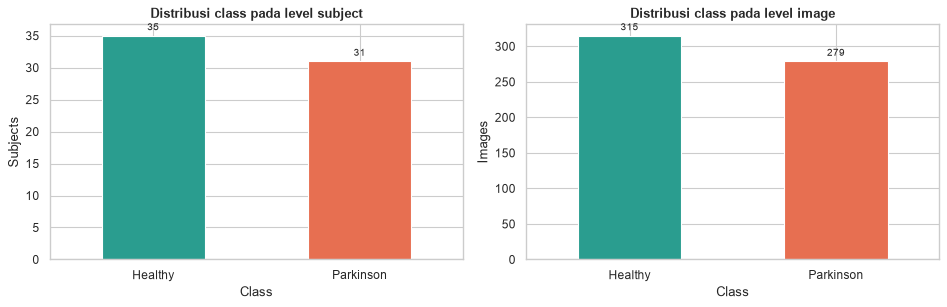

In [7]:
def annotate_bars(axis):
    for container in axis.containers:
        axis.bar_label(container, padding=3, fontsize=9)


subject_class_counts = (
    df_subjects["class_name"].value_counts().reindex(CLASS_ORDER).fillna(0)
)
image_class_counts = (
    df_images["class_name"].value_counts().reindex(CLASS_ORDER).fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
subject_class_counts.plot(
    kind="bar",
    color=[CLASS_COLORS[label] for label in subject_class_counts.index],
    ax=axes[0],
)
axes[0].set(title="Distribusi class pada level subject", xlabel="Class", ylabel="Subjects")
axes[0].tick_params(axis="x", rotation=0)
annotate_bars(axes[0])

image_class_counts.plot(
    kind="bar",
    color=[CLASS_COLORS[label] for label in image_class_counts.index],
    ax=axes[1],
)
axes[1].set(title="Distribusi class pada level image", xlabel="Class", ylabel="Images")
axes[1].tick_params(axis="x", rotation=0)
annotate_bars(axes[1])
plt.tight_layout()
plt.show()

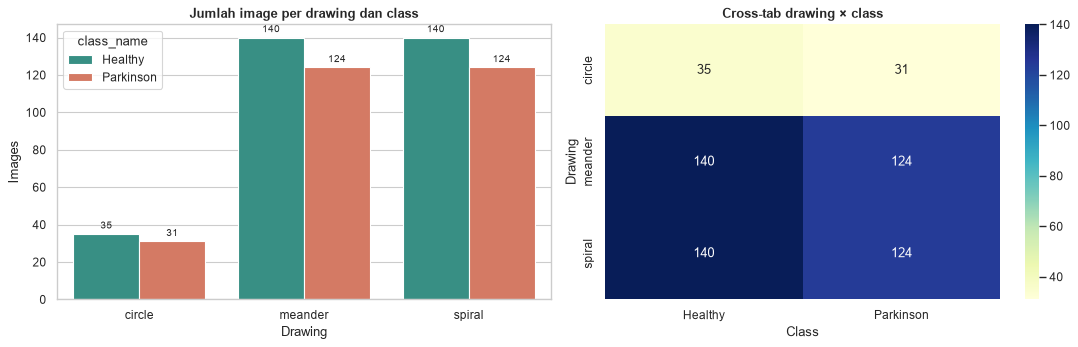

class_name,Healthy,Parkinson
drawing_type,,
circle,35,31
meander,140,124
spiral,140,124


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(
    data=df_images,
    x="drawing_type",
    hue="class_name",
    order=DRAWING_ORDER,
    hue_order=CLASS_ORDER,
    palette=CLASS_COLORS,
    ax=axes[0],
)
axes[0].set(title="Jumlah image per drawing dan class", xlabel="Drawing", ylabel="Images")
annotate_bars(axes[0])

drawing_class_table = pd.crosstab(
    df_images["drawing_type"], df_images["class_name"]
).reindex(index=DRAWING_ORDER, columns=CLASS_ORDER)
sns.heatmap(drawing_class_table, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1])
axes[1].set(title="Cross-tab drawing × class", xlabel="Class", ylabel="Drawing")
plt.tight_layout()
plt.show()
display(drawing_class_table)

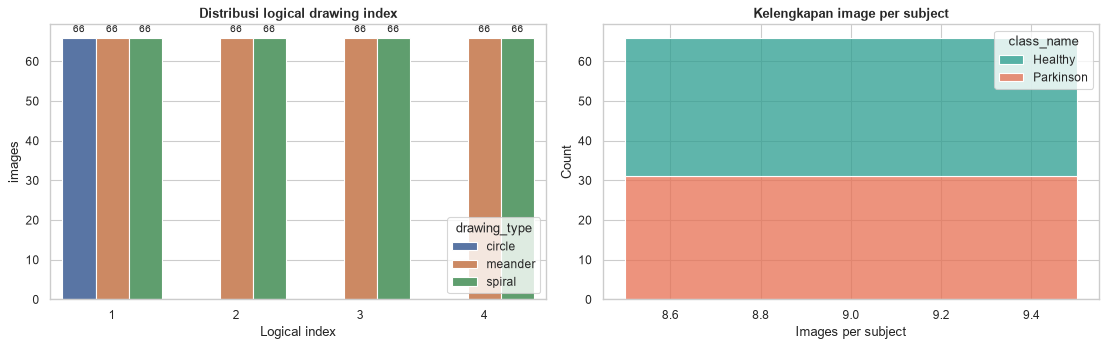

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
index_counts = (
    df_images.groupby(["drawing_type", "drawing_index"], observed=True)
    .size()
    .reset_index(name="images")
)
sns.barplot(
    data=index_counts,
    x="drawing_index",
    y="images",
    hue="drawing_type",
    hue_order=DRAWING_ORDER,
    ax=axes[0],
)
axes[0].set(title="Distribusi logical drawing index", xlabel="Logical index")
annotate_bars(axes[0])

sns.histplot(
    data=df_subjects,
    x="total_images",
    hue="class_name",
    hue_order=CLASS_ORDER,
    palette=CLASS_COLORS,
    multiple="stack",
    discrete=True,
    ax=axes[1],
)
axes[1].set(title="Kelengkapan image per subject", xlabel="Images per subject")
plt.tight_layout()
plt.show()

## 5. Dimensi, file size, dan statistik pixel

`dark_pixel_fraction` adalah proxy seluruh pixel gelap, termasuk template cetak. Nilai ini bukan pengukuran tinta tulisan tangan secara murni.

In [10]:
def calculate_pixel_statistics(relative_path):
    image_path = RAW_DIR / relative_path
    with Image.open(image_path) as image:
        rgb = np.asarray(image.convert("RGB"), dtype=np.float32)
    grayscale = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    return {
        "brightness_mean": float(grayscale.mean()),
        "contrast_std": float(grayscale.std()),
        "dark_pixel_fraction": float((grayscale < 200).mean()),
    }


pixel_statistics = pd.DataFrame(
    [calculate_pixel_statistics(path) for path in df_images["filepath"]]
)
df_eda = pd.concat([df_images.copy(), pixel_statistics], axis=1)
df_eda["aspect_ratio"] = df_eda["width"] / df_eda["height"]
df_eda["megapixels"] = df_eda["width"] * df_eda["height"] / 1_000_000
df_eda["file_size_kb"] = df_eda["file_size_bytes"] / 1024

derived_columns = [
    "width",
    "height",
    "aspect_ratio",
    "megapixels",
    "file_size_kb",
    "brightness_mean",
    "contrast_std",
    "dark_pixel_fraction",
]
display(df_eda[derived_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
width,594.0,586.915825,150.676786,40.000000,572.500000,599.000000,676.000000,822.000000
height,594.0,577.698653,142.221895,45.000000,548.000000,588.000000,674.000000,756.000000
aspect_ratio,594.0,1.009891,0.072274,0.642857,0.992710,1.018282,1.041235,1.562500
megapixels,594.0,0.360013,0.127354,0.001800,0.314394,0.349128,0.458296,0.560472
file_size_kb,594.0,202.914273,143.880491,2.021484,37.256592,237.420410,351.692383,464.309570
brightness_mean,594.0,219.534107,14.410080,168.011673,213.243546,217.629517,234.372921,242.695877
contrast_std,594.0,52.976470,9.434451,31.680107,48.084929,52.605213,56.165619,85.993614
dark_pixel_fraction,594.0,0.147091,0.060567,0.080349,0.118284,0.130264,0.145233,0.449579


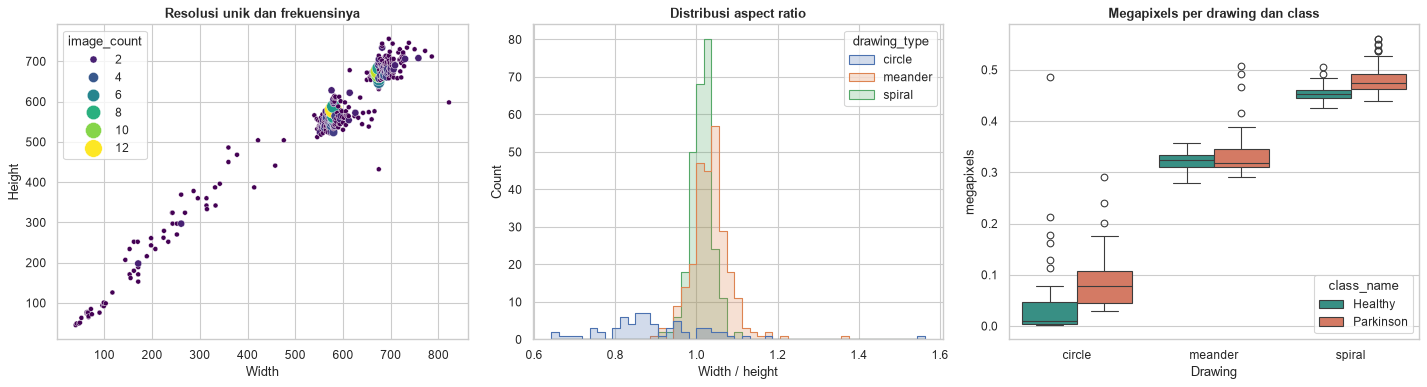

In [11]:
resolution_counts = (
    df_eda.groupby(["width", "height"], observed=True)
    .size()
    .reset_index(name="image_count")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(
    data=resolution_counts,
    x="width",
    y="height",
    size="image_count",
    hue="image_count",
    sizes=(20, 250),
    palette="viridis",
    ax=axes[0],
)
axes[0].set(title="Resolusi unik dan frekuensinya", xlabel="Width", ylabel="Height")

sns.histplot(
    data=df_eda,
    x="aspect_ratio",
    hue="drawing_type",
    hue_order=DRAWING_ORDER,
    element="step",
    common_norm=False,
    ax=axes[1],
)
axes[1].set(title="Distribusi aspect ratio", xlabel="Width / height")

sns.boxplot(
    data=df_eda,
    x="drawing_type",
    y="megapixels",
    hue="class_name",
    order=DRAWING_ORDER,
    hue_order=CLASS_ORDER,
    palette=CLASS_COLORS,
    ax=axes[2],
)
axes[2].set(title="Megapixels per drawing dan class", xlabel="Drawing")
plt.tight_layout()
plt.show()

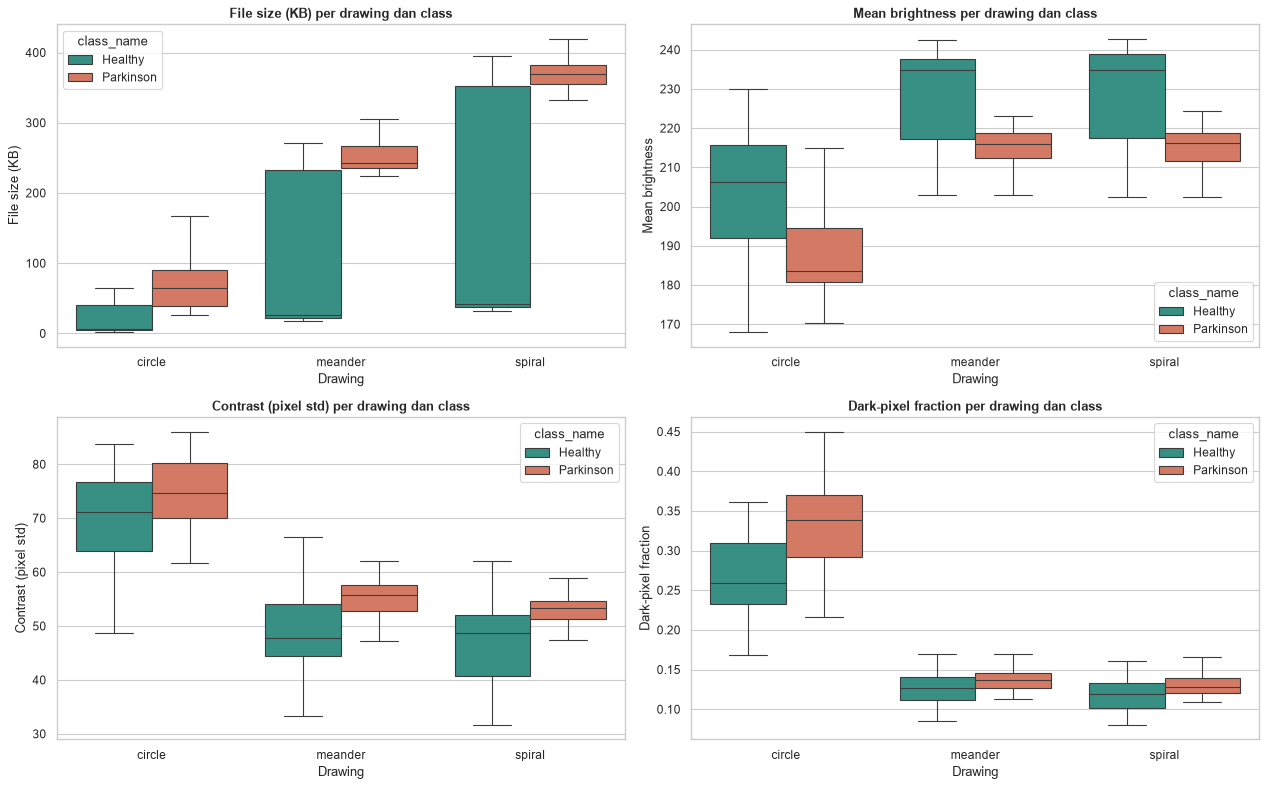

In [12]:
metrics = [
    ("file_size_kb", "File size (KB)"),
    ("brightness_mean", "Mean brightness"),
    ("contrast_std", "Contrast (pixel std)"),
    ("dark_pixel_fraction", "Dark-pixel fraction"),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for axis, (metric, label) in zip(axes.flat, metrics, strict=True):
    sns.boxplot(
        data=df_eda,
        x="drawing_type",
        y=metric,
        hue="class_name",
        order=DRAWING_ORDER,
        hue_order=CLASS_ORDER,
        palette=CLASS_COLORS,
        showfliers=False,
        ax=axis,
    )
    axis.set(title=f"{label} per drawing dan class", xlabel="Drawing", ylabel=label)
plt.tight_layout()
plt.show()

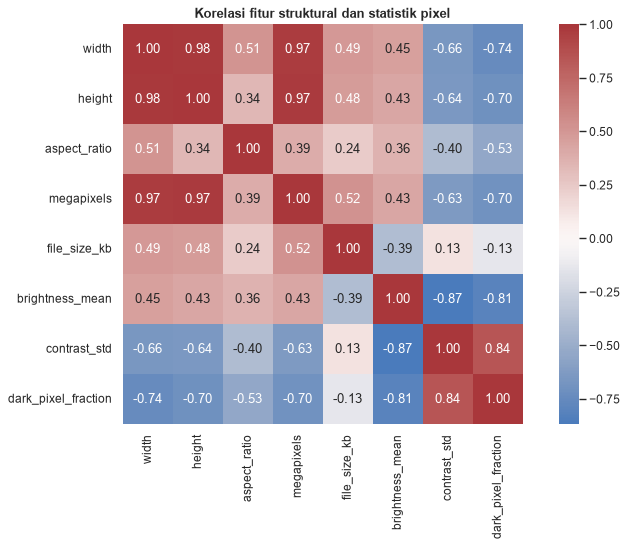

In [13]:
correlation_columns = [
    "width",
    "height",
    "aspect_ratio",
    "megapixels",
    "file_size_kb",
    "brightness_mean",
    "contrast_std",
    "dark_pixel_fraction",
]
correlations = df_eda[correlation_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
)
plt.title("Korelasi fitur struktural dan statistik pixel")
plt.tight_layout()
plt.show()

## 6. Galeri sampel terstratifikasi

Dua sampel dipilih secara deterministik untuk setiap kombinasi class dan drawing. Galeri digunakan untuk memeriksa template, orientasi, warna, crop, serta variasi visual.

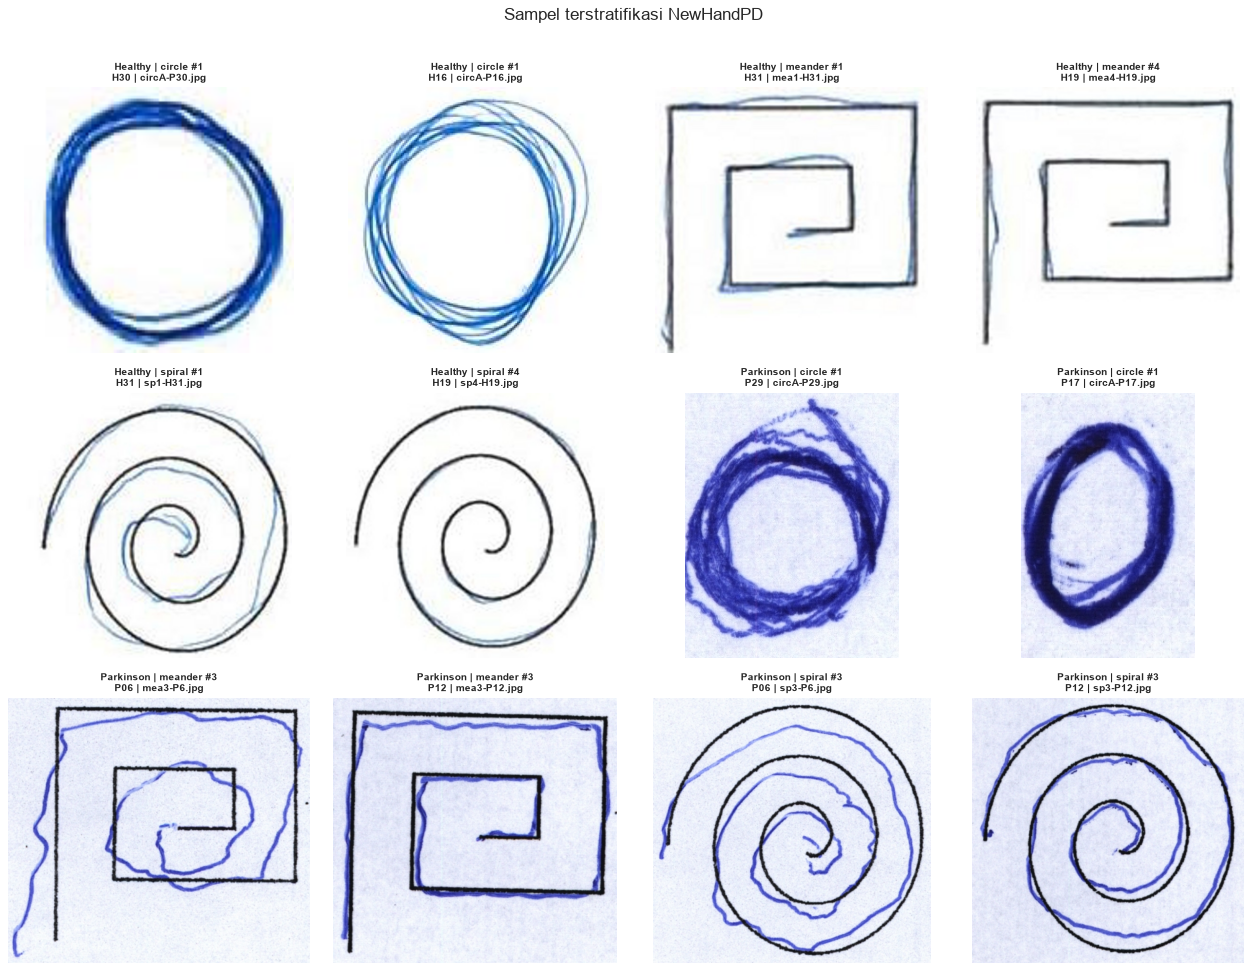

In [14]:
def load_thumbnail(relative_path, max_size=(420, 420)):
    with Image.open(RAW_DIR / relative_path) as image:
        thumbnail = image.convert("RGB")
        thumbnail.thumbnail(max_size)
        return thumbnail.copy()


sample_groups = []
for _, group in df_eda.groupby(["class_name", "drawing_type"], sort=True):
    sample_groups.append(group.sample(n=min(2, len(group)), random_state=42))
gallery_rows = pd.concat(sample_groups).sort_values(["class_name", "drawing_type"])

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for axis, (_, row) in zip(axes.flat, gallery_rows.iterrows(), strict=True):
    axis.imshow(load_thumbnail(row["filepath"]))
    axis.set_title(
        f"{row['class_name']} | {row['drawing_type']} #{row['drawing_index']}\n"
        f"{row['subject_id']} | {row['filename']}",
        fontsize=9,
    )
    axis.axis("off")
plt.suptitle("Sampel terstratifikasi NewHandPD", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

## 7. Analisis anomaly flags

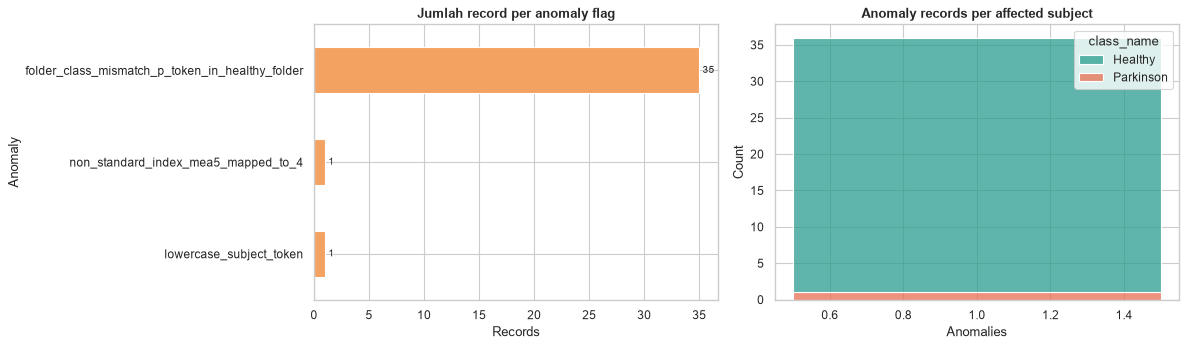

,filepath,raw_subject_token,subject_id,anomaly_flags
0,HealthyCircle/circA-P1.jpg,P1,H01,folder_class_mismatch_p_token_in_healthy_folder
1,HealthyCircle/circA-P2.jpg,P2,H02,folder_class_mismatch_p_token_in_healthy_folder
2,HealthyCircle/circA-P3.jpg,P3,H03,folder_class_mismatch_p_token_in_healthy_folder
3,HealthyCircle/circA-P4.jpg,P4,H04,folder_class_mismatch_p_token_in_healthy_folder
4,HealthyCircle/circA-P5.jpg,P5,H05,folder_class_mismatch_p_token_in_healthy_folder
5,HealthyCircle/circA-P7.jpg,P7,H07,folder_class_mismatch_p_token_in_healthy_folder
6,HealthyCircle/circA-P8.jpg,P8,H08,folder_class_mismatch_p_token_in_healthy_folder
7,HealthyCircle/circA-P9.jpg,P9,H09,folder_class_mismatch_p_token_in_healthy_folder
8,HealthyCircle/circA-P10.jpg,P10,H10,folder_class_mismatch_p_token_in_healthy_folder
9,HealthyCircle/circA-P11.jpg,P11,H11,folder_class_mismatch_p_token_in_healthy_folder


In [15]:
anomaly_rows = df_images.loc[df_images["anomaly_flags"] != "none"].copy()
anomaly_exploded = (
    anomaly_rows.assign(anomaly=anomaly_rows["anomaly_flags"].str.split(","))
    .explode("anomaly")
    .groupby("anomaly", observed=True)
    .size()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
anomaly_exploded.sort_values().plot(kind="barh", color="#F4A261", ax=axes[0])
axes[0].set(title="Jumlah record per anomaly flag", xlabel="Records", ylabel="Anomaly")
annotate_bars(axes[0])

subject_anomaly_counts = (
    anomaly_rows.groupby(["subject_id", "class_name"], observed=True)
    .size()
    .reset_index(name="anomaly_records")
)
sns.histplot(
    data=subject_anomaly_counts,
    x="anomaly_records",
    hue="class_name",
    hue_order=CLASS_ORDER,
    palette=CLASS_COLORS,
    multiple="stack",
    discrete=True,
    ax=axes[1],
)
axes[1].set(title="Anomaly records per affected subject", xlabel="Anomalies")
plt.tight_layout()
plt.show()
display(anomaly_rows[["filepath", "raw_subject_token", "subject_id", "anomaly_flags"]])

## 8. Exact duplicate analysis

Exact duplicate ditentukan oleh SHA-256 yang identik. Subject yang terhubung oleh exact duplicate harus menjadi satu effective group saat splitting.

In [16]:
exact_group_summary = (
    df_exact.groupby("duplicate_group_id", observed=True)
    .agg(
        image_count=("filepath", "size"),
        subject_count=("subject_id", "nunique"),
        drawing_count=("drawing_type", "nunique"),
        class_count=("class_name", "nunique"),
    )
    .reset_index()
)
exact_summary = pd.Series(
    {
        "exact_groups": df_exact["duplicate_group_id"].nunique(),
        "images_in_exact_groups": len(df_exact),
        "cross_subject_groups": int((exact_group_summary["subject_count"] > 1).sum()),
        "cross_drawing_groups": int((exact_group_summary["drawing_count"] > 1).sum()),
        "cross_class_groups": int((exact_group_summary["class_count"] > 1).sum()),
    },
    name="value",
)
display(exact_summary.to_frame())
display(exact_group_summary.head(10))

,value
exact_groups,36
images_in_exact_groups,80
cross_subject_groups,36
cross_drawing_groups,0
cross_class_groups,0


,duplicate_group_id,image_count,subject_count,drawing_count,class_count
0,dup_001,3,3,1,1
1,dup_002,2,2,1,1
2,dup_003,2,2,1,1
3,dup_004,2,2,1,1
4,dup_005,2,2,1,1
5,dup_006,3,3,1,1
6,dup_007,2,2,1,1
7,dup_008,2,2,1,1
8,dup_009,3,3,1,1
9,dup_010,2,2,1,1


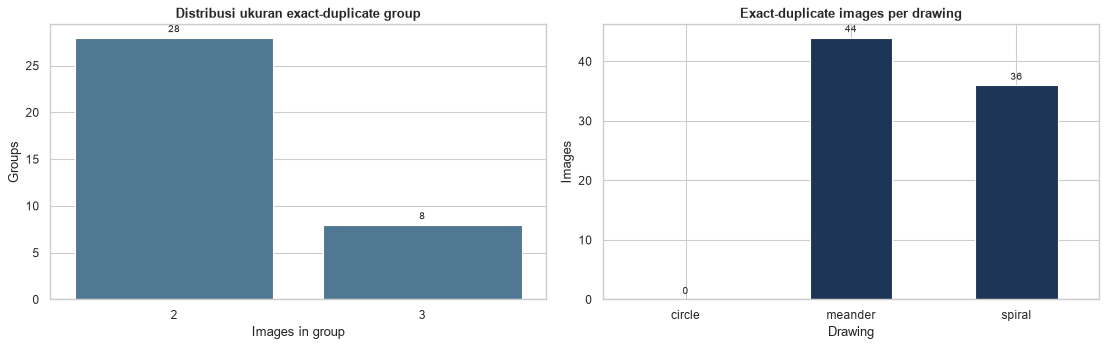

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(
    data=exact_group_summary,
    x="image_count",
    color="#457B9D",
    ax=axes[0],
)
axes[0].set(title="Distribusi ukuran exact-duplicate group", xlabel="Images in group", ylabel="Groups")
annotate_bars(axes[0])

exact_drawing_counts = df_exact["drawing_type"].value_counts().reindex(DRAWING_ORDER).fillna(0)
exact_drawing_counts.plot(kind="bar", color="#1D3557", ax=axes[1])
axes[1].set(title="Exact-duplicate images per drawing", xlabel="Drawing", ylabel="Images")
axes[1].tick_params(axis="x", rotation=0)
annotate_bars(axes[1])
plt.tight_layout()
plt.show()

## 9. Near-duplicate candidate analysis

dHash adalah screening hook, bukan keputusan duplicate final. Pasangan dengan template serupa dapat menjadi false positive.

,value
candidate_pairs,36
cross_subject_pairs,31
cross_class_pairs,14
minimum_hamming_distance,1
maximum_hamming_distance,2


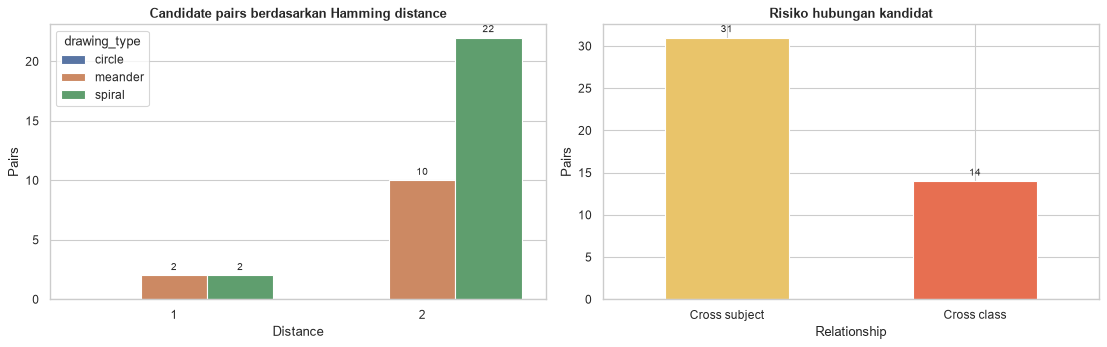

In [18]:
df_near_analysis = df_near.copy()
df_near_analysis["cross_subject"] = (
    df_near_analysis["subject_id_a"] != df_near_analysis["subject_id_b"]
)
df_near_analysis["cross_class"] = (
    df_near_analysis["class_name_a"] != df_near_analysis["class_name_b"]
)

near_summary = pd.Series(
    {
        "candidate_pairs": len(df_near_analysis),
        "cross_subject_pairs": int(df_near_analysis["cross_subject"].sum()),
        "cross_class_pairs": int(df_near_analysis["cross_class"].sum()),
        "minimum_hamming_distance": int(df_near_analysis["hamming_distance"].min()),
        "maximum_hamming_distance": int(df_near_analysis["hamming_distance"].max()),
    },
    name="value",
)
display(near_summary.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.countplot(
    data=df_near_analysis,
    x="hamming_distance",
    hue="drawing_type",
    hue_order=DRAWING_ORDER,
    ax=axes[0],
)
axes[0].set(title="Candidate pairs berdasarkan Hamming distance", xlabel="Distance", ylabel="Pairs")
annotate_bars(axes[0])

near_flags = df_near_analysis[["cross_subject", "cross_class"]].sum().rename(
    {"cross_subject": "Cross subject", "cross_class": "Cross class"}
)
near_flags.plot(kind="bar", color=["#E9C46A", "#E76F51"], ax=axes[1])
axes[1].set(title="Risiko hubungan kandidat", xlabel="Relationship", ylabel="Pairs")
axes[1].tick_params(axis="x", rotation=0)
annotate_bars(axes[1])
plt.tight_layout()
plt.show()

## 10. Galeri seluruh kandidat near-duplicate

Setiap baris memperlihatkan pasangan A dan B. Perhatikan stroke tulisan, crop, noise, compression, dan template. Kesamaan template saja tidak cukup untuk keputusan `confirmed_duplicate`.

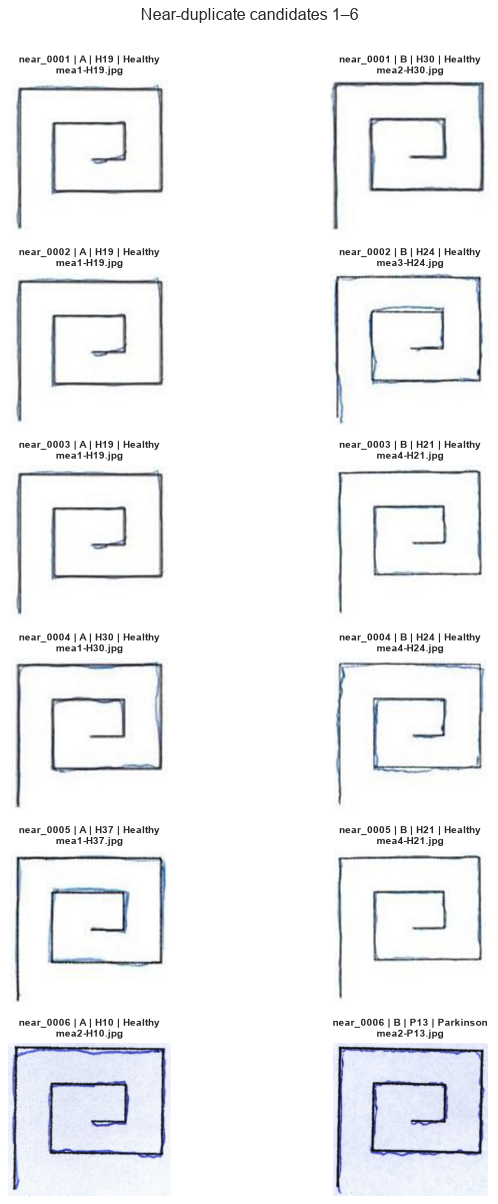

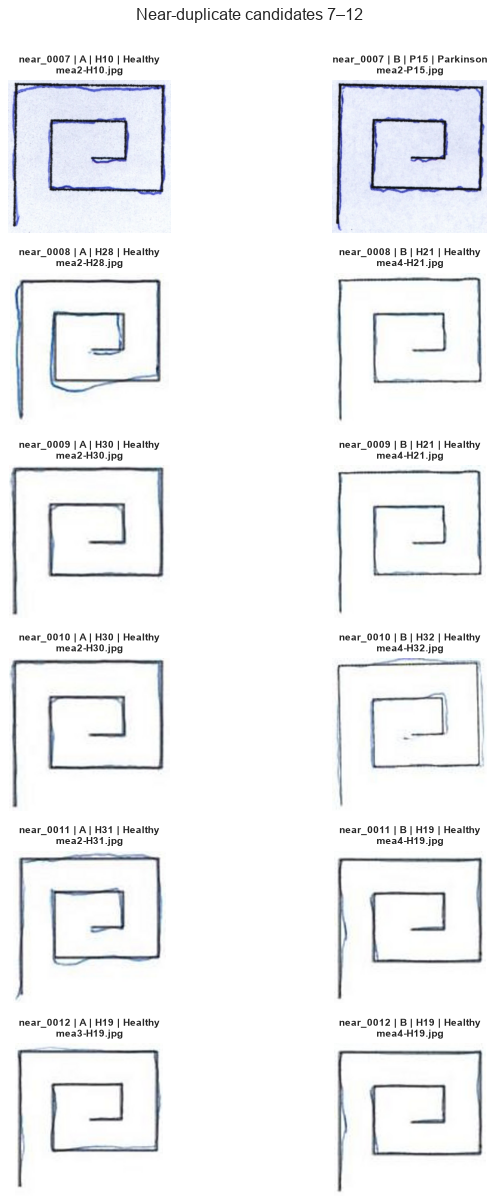

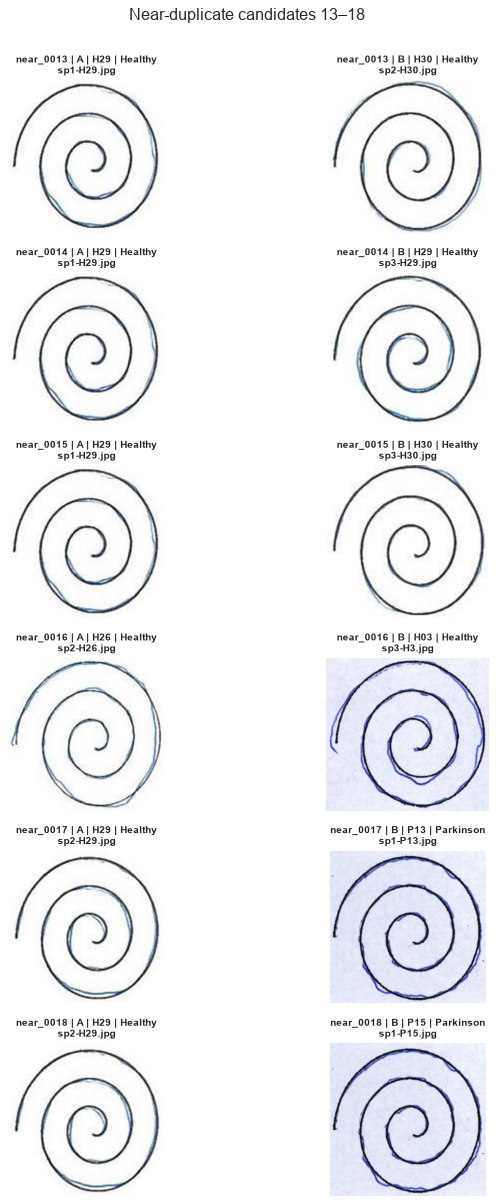

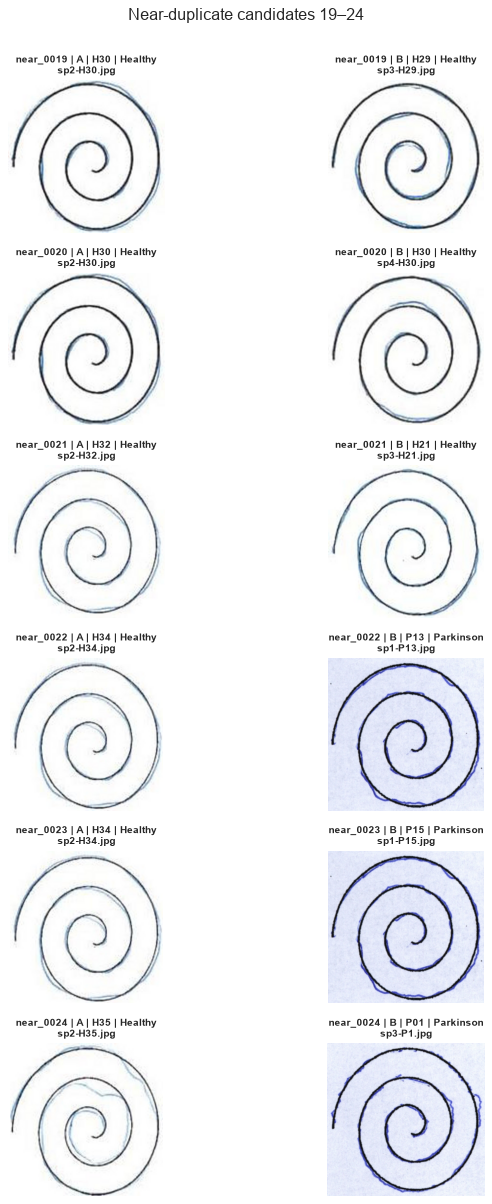

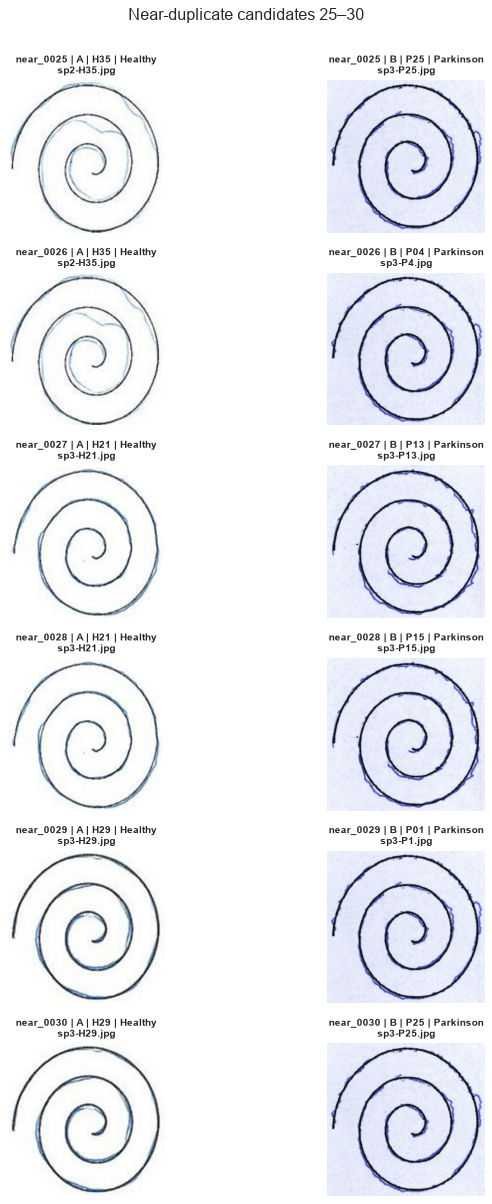

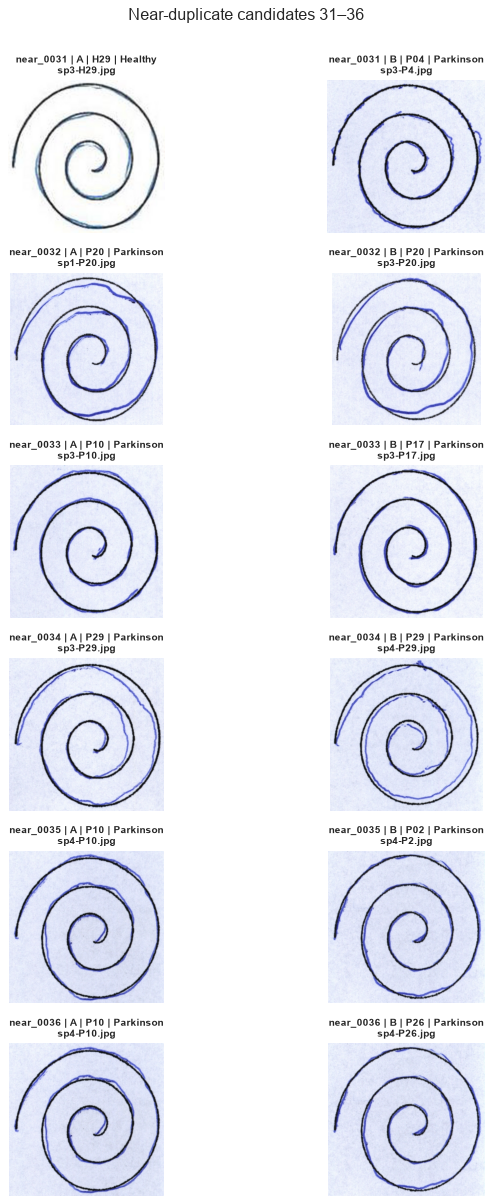

In [19]:
def show_near_duplicate_page(start, pairs_per_page=6):
    page = df_near_analysis.iloc[start : start + pairs_per_page]
    if page.empty:
        return
    fig, axes = plt.subplots(len(page), 2, figsize=(10, 2.5 * len(page)), squeeze=False)
    for row_index, (_, candidate) in enumerate(page.iterrows()):
        for column, suffix in enumerate(("a", "b")):
            filepath = candidate[f"filepath_{suffix}"]
            axes[row_index, column].imshow(load_thumbnail(filepath))
            axes[row_index, column].set_title(
                f"{candidate['candidate_id']} | {suffix.upper()} | "
                f"{candidate[f'subject_id_{suffix}']} | {candidate[f'class_name_{suffix}']}\n"
                f"{Path(filepath).name}",
                fontsize=9,
            )
            axes[row_index, column].axis("off")
        axes[row_index, 0].set_ylabel(
            f"{candidate['drawing_type']}\ndHash distance={candidate['hamming_distance']}",
            fontsize=9,
        )
    fig.suptitle(
        f"Near-duplicate candidates {start + 1}–{start + len(page)}",
        y=1.002,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


for page_start in range(0, len(df_near_analysis), 6):
    show_near_duplicate_page(page_start)

## 11. Manifest keputusan near-duplicate

Nilai `decision` yang diperbolehkan:

- `pending`: belum direview;
- `confirmed_duplicate`: secara visual dianggap duplicate;
- `false_positive`: mirip menurut dHash tetapi bukan duplicate;
- `uncertain`: membutuhkan review tambahan.

Edit `near_duplicate_review.csv` secara manual. Cell berikut mempertahankan keputusan lama ketika notebook dijalankan ulang dan menambahkan kandidat baru jika audit berubah.

In [20]:
review_path = METADATA_DIR / "near_duplicate_review.csv"
review_base = df_near_analysis[
    [
        "candidate_id",
        "filepath_a",
        "filepath_b",
        "subject_id_a",
        "subject_id_b",
        "class_name_a",
        "class_name_b",
        "drawing_type",
        "hamming_distance",
        "cross_subject",
        "cross_class",
    ]
].copy()

review_columns = ["candidate_id", "decision", "reviewer", "notes"]
if review_path.exists():
    previous_review = pd.read_csv(review_path, keep_default_na=False)
    preserved_columns = [column for column in review_columns if column in previous_review]
    review_manifest = review_base.merge(
        previous_review[preserved_columns], on="candidate_id", how="left"
    )
else:
    review_manifest = review_base.copy()

for column, default_value in {
    "decision": "pending",
    "reviewer": "",
    "notes": "",
}.items():
    if column not in review_manifest:
        review_manifest[column] = default_value
    review_manifest[column] = review_manifest[column].fillna(default_value)
    if column == "decision":
        review_manifest.loc[review_manifest[column] == "", column] = default_value

review_manifest.to_csv(review_path, index=False, lineterminator="\n")
print(f"Review manifest: {review_path}")
display(review_manifest.head(10))
display(review_manifest["decision"].value_counts().rename("pairs").to_frame())

Review manifest: D:\project\parkindraw-ai\data\metadata\near_duplicate_review.csv


,candidate_id,filepath_a,filepath_b,subject_id_a,subject_id_b,class_name_a,class_name_b,drawing_type,hamming_distance,cross_subject,cross_class,decision,reviewer,notes
0,near_0001,HealthyMeander/mea1-H19.jpg,HealthyMeander/mea2-H30.jpg,H19,H30,Healthy,Healthy,meander,1,True,False,pending,,
1,near_0002,HealthyMeander/mea1-H19.jpg,HealthyMeander/mea3-H24.jpg,H19,H24,Healthy,Healthy,meander,2,True,False,pending,,
2,near_0003,HealthyMeander/mea1-H19.jpg,HealthyMeander/mea4-H21.jpg,H19,H21,Healthy,Healthy,meander,2,True,False,pending,,
3,near_0004,HealthyMeander/mea1-H30.jpg,HealthyMeander/mea4-H24.jpg,H30,H24,Healthy,Healthy,meander,2,True,False,pending,,
4,near_0005,HealthyMeander/mea1-H37.jpg,HealthyMeander/mea4-H21.jpg,H37,H21,Healthy,Healthy,meander,2,True,False,pending,,
5,near_0006,HealthyMeander/mea2-H10.jpg,PatientMeander/mea2-P13.jpg,H10,P13,Healthy,Parkinson,meander,2,True,True,pending,,
6,near_0007,HealthyMeander/mea2-H10.jpg,PatientMeander/mea2-P15.jpg,H10,P15,Healthy,Parkinson,meander,2,True,True,pending,,
7,near_0008,HealthyMeander/mea2-H28.jpg,HealthyMeander/mea4-H21.jpg,H28,H21,Healthy,Healthy,meander,2,True,False,pending,,
8,near_0009,HealthyMeander/mea2-H30.jpg,HealthyMeander/mea4-H21.jpg,H30,H21,Healthy,Healthy,meander,1,True,False,pending,,
9,near_0010,HealthyMeander/mea2-H30.jpg,HealthyMeander/mea4-H32.jpg,H30,H32,Healthy,Healthy,meander,2,True,False,pending,,


,pairs
decision,
pending,36


## 12. Data-readiness summary dan langkah berikutnya

In [21]:
pending_reviews = int((review_manifest["decision"] == "pending").sum())
uncertain_reviews = int((review_manifest["decision"] == "uncertain").sum())
readiness = pd.Series(
    {
        "audit_passed": audit_report["status"] == "passed",
        "metadata_integrity_passed": bool(integrity_checks.all()),
        "all_images_fully_decodable": audit_report["corrupted_images_count"] == 0,
        "exact_duplicates_mapped": audit_report["exact_duplicate_groups_count"] == 36,
        "near_candidates_reported": len(df_near_analysis) == 36,
        "near_review_complete": pending_reviews == 0 and uncertain_reviews == 0,
    },
    name="ready",
)
display(readiness.to_frame())
print(f"Pending reviews   : {pending_reviews}")
print(f"Uncertain reviews : {uncertain_reviews}")

if readiness["near_review_complete"]:
    print("Data siap memasuki pembentukan effective groups dan leakage-safe split.")
else:
    print("Selesaikan near-duplicate review sebelum split Fase 2 dikunci.")

,ready
audit_passed,True
metadata_integrity_passed,True
all_images_fully_decodable,True
exact_duplicates_mapped,True
near_candidates_reported,True
near_review_complete,False


Pending reviews   : 36
Uncertain reviews : 0
Selesaikan near-duplicate review sebelum split Fase 2 dikunci.


## 13. Interpretasi dan batasan

1. Dataset kecil: 66 subjek dari satu sumber pengumpulan.
2. Sembilan gambar dari subjek yang sama tidak boleh dianggap sembilan observasi independen saat splitting.
3. Exact duplicate dan confirmed near-duplicate dapat menghubungkan beberapa subject menjadi satu effective group.
4. dHash sensitif terhadap struktur visual umum dan dapat menandai template yang mirip sebagai kandidat.
5. Statistik brightness, contrast, dan dark-pixel fraction mencakup tulisan serta template cetak.
6. Perbandingan visual berdasarkan label pada notebook ini hanya digunakan untuk mendeteksi masalah akuisisi atau confound. Preprocessing dan modeling EDA harus dikembangkan pada development set setelah test set dikunci.
7. Domain gambar NewHandPD belum tentu sama dengan canvas browser atau foto pengguna aplikasi.

### Keputusan berikutnya

1. Isi `near_duplicate_review.csv` sampai tidak ada `pending` atau `uncertain`.
2. Bentuk connected/effective groups dari subject, exact duplicate, dan confirmed near-duplicate.
3. Buat grouped holdout test set.
4. Buat 3-fold Stratified Group K-Fold hanya pada development set.
5. Jalankan modeling EDA pada development set, bukan seluruh dataset.